In [ ]:
try:
    %reload_ext autoreload
except:
    %load_ext autoreload
%autoreload 2

# Basic useful imports
from pathlib import Path
import h5py

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import ScalarFormatter

from itertools import cycle
# plt.cm.tab20.colors

# From alens_analysis.py
import alens_analysis as aa

# Functions for my simulations
from dyn_cond_fig_functions import *


# Locations
ws_path = Path('/home/alamson/DATA/Chromatin/')
mnt_path = Path.home() / 'projects/DATA/Chromatin/'
ceph_path = Path.home() / 'ceph/DATA/Chromatin/'

In [7]:
def bin_data(time_arr, data_arr, bin_size=10.0):
    """
    Bin data by time intervals.
    
    Parameters
    ----------
    time_arr : array-like
        Time values
    data_arr : array-like
        Data values to bin
    bin_size : float
        Size of time bins in seconds (default: 10.0)
    
    Returns
    -------
    binned_time : array
        Centers of time bins
    binned_data : array
        Averaged data within each bin
    """
    # Create bin edges
    min_time = time_arr[0]
    max_time = time_arr[-1]
    bin_edges = np.arange(min_time, max_time + bin_size, bin_size)
    
    # Digitize to find which bin each time point belongs to
    bin_indices = np.digitize(time_arr, bin_edges)
    
    # Calculate mean for each bin
    binned_time = []
    binned_data = []
    
    for i in range(1, len(bin_edges)):
        mask = bin_indices == i
        if np.any(mask):
            binned_time.append(np.mean(time_arr[mask]))
            binned_data.append(np.mean(data_arr[mask]))
    
    return np.array(binned_time), np.array(binned_data)

### Style settings

In [8]:
graph_sty = {
    "axes.titlesize": 20,
    "axes.labelsize": 24,
    "lines.linewidth": 2,
    "lines.markersize": 10,
    "xtick.labelsize": 24,
    "ytick.labelsize": 24,
    "font.size": 20,
    # "font.sans-serif": 'Helvetica',
    "text.usetex": False,
    'mathtext.fontset': 'cm',
}
plt.style.use(graph_sty)


formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-3, 3))

colors = cycle(mcolors.XKCD_COLORS.keys())

plt.rcParams['image.cmap'] = 'YlOrRd'
        

In [17]:
# Consistent settings
ss_ind = 1
end_ind = -1
start_bead = 0
end_bead = None
part_min = 40

# System parameters
L_tot = 1600
L_tot_um = 16.0

# Diffusion time
visc = 1.0 # pN*s/um^2
b_diam = 0.01 # um
kbT = .00411 # pN*um
bead_diff = kbT / (3 * np.pi * visc * b_diam) # um^2/s
diff_time = b_diam**3*3.*np.pi*visc / (6.*kbT) # s
print(f"Diffusion time: {diff_time:.5f} s")

Diffusion time: 0.00038 s


# Graph averages

In [ ]:
# Load data
loaded_tension_data_dict = {}
with h5py.File("avg_tension_data.h5", 'r') as h5_file:
    for ell_key in h5_file.keys():
        if ell_key == "time":
            continue
        ell_group = h5_file[ell_key]
        ell = int(ell_key.split('_')[1])
        tension_dict = {}
        for Ke_key in ell_group.keys():
            Ke = int(Ke_key.split('_')[1])
            tension_data = ell_group[Ke_key][:]
            tension_dict[Ke] = tension_data
        loaded_tension_data_dict[ell] = tension_dict
    loaded_time_arr = h5_file["time"][:]

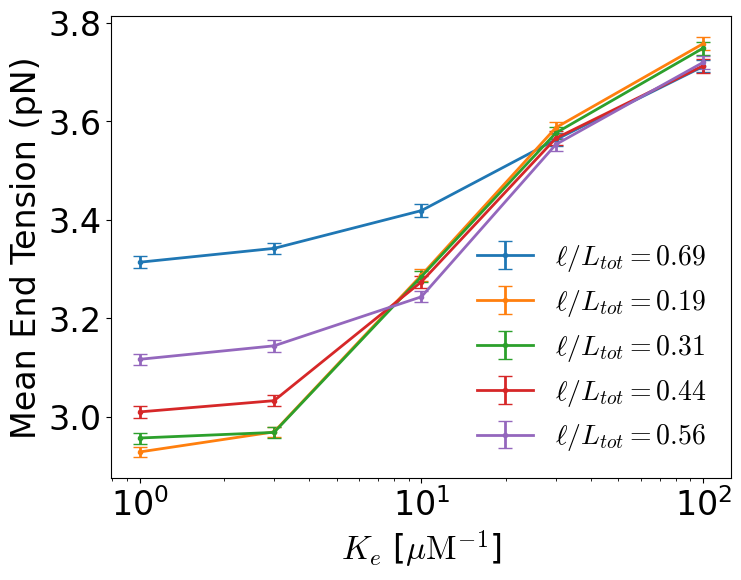

In [70]:
fig, ax = plt.subplots(figsize=(8,6))
for ell, tension_dict in loaded_tension_data_dict.items():
    Ke_vals = sorted(tension_dict.keys())
    mean_tensions = []
    std_tensions = []
    for Ke in Ke_vals:
        tension_data = tension_dict[Ke]
        mean_tensions.append(np.mean(tension_data))

        std_tensions.append((np.std(tension_data) / np.sqrt(len(tension_data))*1.96))  # 95% confidence interval

    _ = ax.errorbar(Ke_vals, mean_tensions, yerr=std_tensions, 
                    marker='o', markersize=3, capsize=5, label=f"$\\ell/L_{{tot}}={ell/L_tot_um:.2f}$")

_ = ax.set_xscale('log')
# _ = ax.set_xlabel("Ke")
_ = ax.set_xlabel(r"$K_e$ [$\mu {\rm M}^{-1}$]")
_ = ax.set_ylabel("Mean End Tension (pN)")
_ = ax.legend(frameon=False)


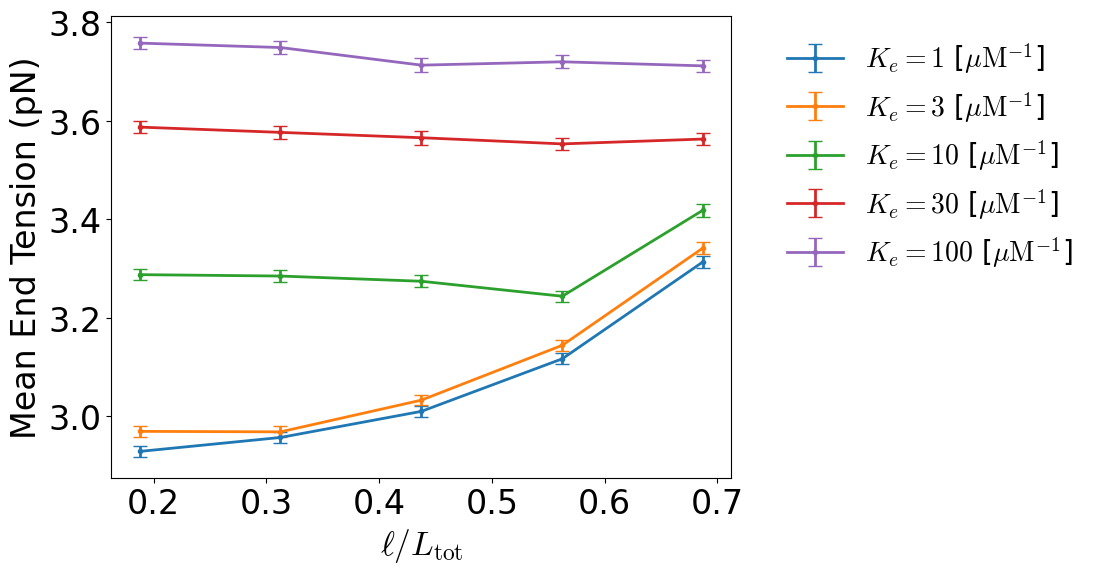

In [71]:
fig, ax = plt.subplots(figsize=(8,6))

ell_vals = sorted(loaded_tension_data_dict.keys())
Ke_vals = sorted(next(iter(loaded_tension_data_dict.values())).keys())
for Ke in Ke_vals:
    mean_tensions = []
    std_tensions = []
    for ell in ell_vals:
        tension_dict = loaded_tension_data_dict[ell]
        tension_data = tension_dict[Ke]
        mean_tensions.append(np.mean(tension_data))
        std_tensions.append((np.std(tension_data) / np.sqrt(len(tension_data))*1.96))  # 95% confidence interval

    _ = ax.errorbar([ell/L_tot_um for ell in ell_vals], mean_tensions, yerr=std_tensions, 
                    marker='o',markersize=3, capsize=5, label=rf"$K_e={Ke}$ [$\mu {{\rm M}}^{{-1}}$]")
    # _ = ax.scatter([ell/L_tot_um for ell in ell_vals], mean_tensions, label=rf"$K_e={Ke}$ [$\mu {{\rm M}}^{{-1}}$]")

# _ = ax.set_xlabel("Ke")
_ = ax.set_xlabel(r"$\ell/L_{\rm tot}$")
_ = ax.set_ylabel("Mean End Tension (pN)")
_ = ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)


# Single test

[0.00000000e+00 0.00000000e+00 1.30825363e+03 ... 1.09854057e+07
 1.09867140e+07 1.09880223e+07]


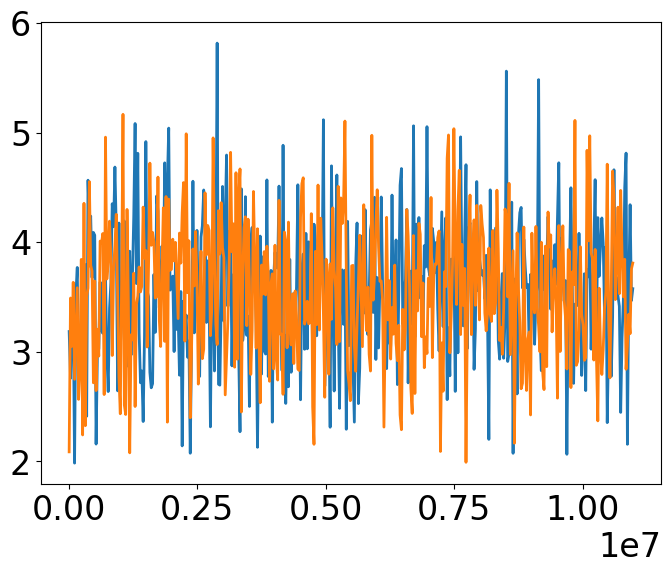

In [11]:
data_path = (ceph_path /"DynCondPaper/24-03-08_aLc1_slice5.5.13_line1600_Pin3-11um_2xKe3-300_ks100/simulations/Ke30_Pin5.0um/s1/analysis")
bead_window = 11 
ss_ind = 0
end_ind = -1
start_bead = 0
end_bead = -1
fig, ax = plt.subplots(figsize=(8,6))
with h5py.File(next(data_path.glob('raw_data.h5')), 'r+') as h5_data:
    time_arr = h5_data['time'][ss_ind:end_ind]/diff_time
    print(time_arr)
    tension_arr = aa.get_link_tension(h5_data)[:,ss_ind:end_ind]
binned_time_0, binned_tension_0 = bin_data(time_arr, tension_arr[0,:], bin_size=10.0/diff_time)
binned_time_1, binned_tension_1 = bin_data(time_arr, tension_arr[-1,:], bin_size=10.0/diff_time)

_ = ax.plot(binned_time_0, binned_tension_0)
_ = ax.plot(binned_time_1, binned_tension_1)

[0.00000000e+00 1.30825363e+03 2.61650726e+03 ... 1.09854057e+07
 1.09867140e+07 1.09880223e+07]


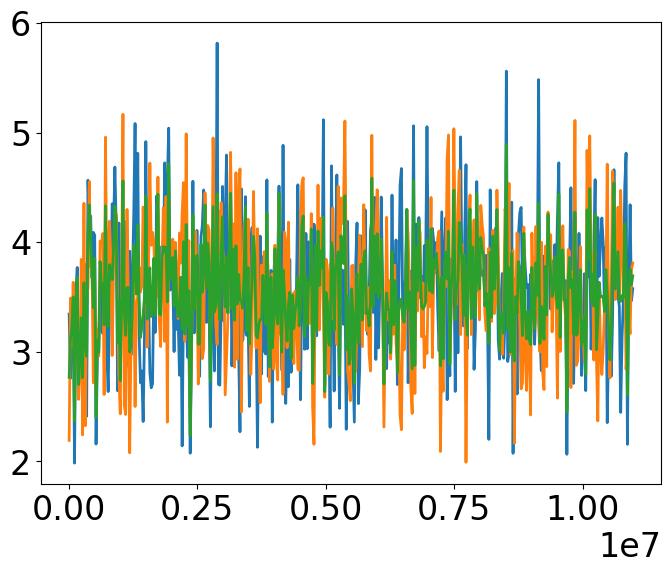

In [18]:
data_path = (ceph_path /"DynCondPaper/24-03-08_aLc1_slice5.5.13_line1600_Pin3-11um_2xKe3-300_ks100/simulations/Ke30_Pin5.0um/s1/analysis")

fig, ax = plt.subplots(figsize=(8,6))
with h5py.File(next(data_path.glob('raw_data.h5')), 'r+') as h5_data:
    time_arr = h5_data['time'][ss_ind:end_ind]/diff_time
    print(time_arr)
    tension_arr = aa.get_link_tension(h5_data)[:,ss_ind:end_ind]
binned_time_0, binned_tension_0 = bin_data(time_arr, tension_arr[0,:], bin_size=10.0/diff_time)
binned_time_1, binned_tension_1 = bin_data(time_arr, tension_arr[-1,:], bin_size=10.0/diff_time)
binned_time_avg, binned_tension_avg = bin_data(time_arr, (tension_arr[0,:] + tension_arr[-1,:])*.5, bin_size=10.0/diff_time)


_ = ax.plot(binned_time_0, binned_tension_0)
_ = ax.plot(binned_time_1, binned_tension_1)
_ = ax.plot(binned_time_avg, binned_tension_avg)

# Parameter run average

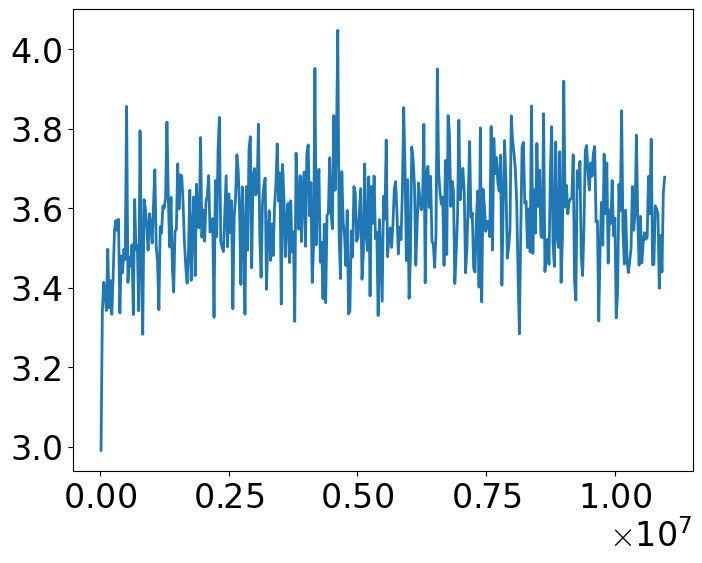

In [24]:
param_data_path = (ceph_path /"DynCondPaper/24-03-08_aLc1_slice5.5.13_line1600_Pin3-11um_2xKe3-300_ks100/simulations/Ke30_Pin5.0um")

tension_arr_list = []
for data_path in param_data_path.glob('s*/analysis'):
    with h5py.File(next(data_path.glob('raw_data.h5')), 'r+') as h5_data:
        time_arr = h5_data['time'][ss_ind:end_ind]/diff_time
        tension_arr = aa.get_link_tension(h5_data)[:,ss_ind:end_ind]
        end_tension_arr = (tension_arr[-1,:] + tension_arr[0,:]) * 0.5
        tension_arr_list.append(end_tension_arr)

binned_time_avg, binned_tension_avg = bin_data(time_arr, np.mean(tension_arr_list, axis=0), bin_size=10.0/diff_time)

fig, ax = plt.subplots(figsize=(8,6))
_ = ax.xaxis.set_major_formatter(formatter)
_ = ax.plot(binned_time_avg, binned_tension_avg)


# Single parameter scans

In [34]:
avg_tension_data_dict = {}

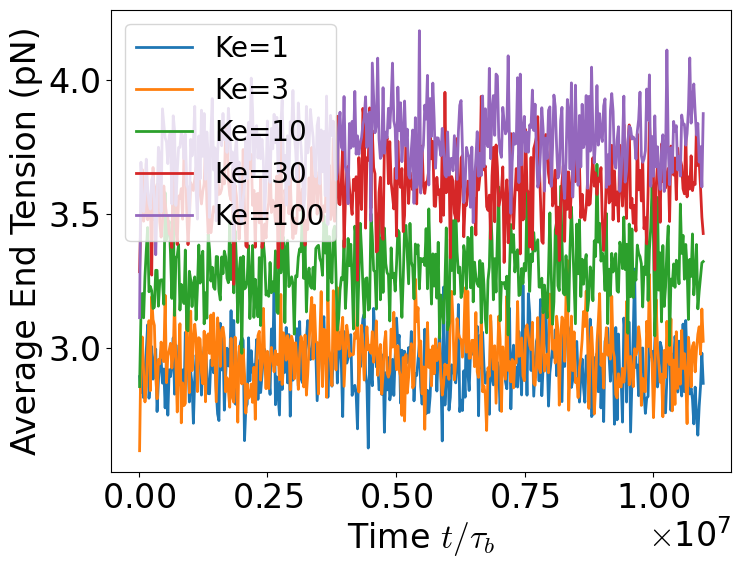

In [35]:
ell_val = 3
Ke_vals = [1, 3, 10, 30, 100]

fig, ax = plt.subplots(figsize=(8,6))
avg_tension_dict = {}
for Ke in Ke_vals:
    param_data_path = (ceph_path /f"DynCondPaper/24-03-08_aLc1_slice5.5.13_line1600_Pin3-11um_2xKe3-300_ks100/simulations/Ke{Ke}_Pin{ell_val}.0um")
    tension_arr_list = []
    for data_path in param_data_path.glob('s*/analysis'):
        with h5py.File(next(data_path.glob('raw_data.h5')), 'r+') as h5_data:
            time_arr = h5_data['time'][ss_ind:end_ind]/diff_time
            tension_arr = aa.get_link_tension(h5_data)[:,ss_ind:end_ind]
            end_tension_arr = (tension_arr[-1,:] + tension_arr[0,:]) * 0.5
            tension_arr_list.append(end_tension_arr)

    binned_time_avg, binned_tension_avg = bin_data(time_arr, np.mean(tension_arr_list, axis=0), bin_size=10.0/diff_time)
    avg_tension_dict[Ke] = binned_tension_avg

    _ = ax.xaxis.set_major_formatter(formatter)
    _ = ax.plot(binned_time_avg, binned_tension_avg, label=f"Ke={Ke}")
    _ = ax.set_xlabel("Time $t/\\tau_{b}$")
    _ = ax.set_ylabel("Average End Tension (pN)")
    _ = ax.legend()
avg_tension_data_dict[ell_val] = avg_tension_dict

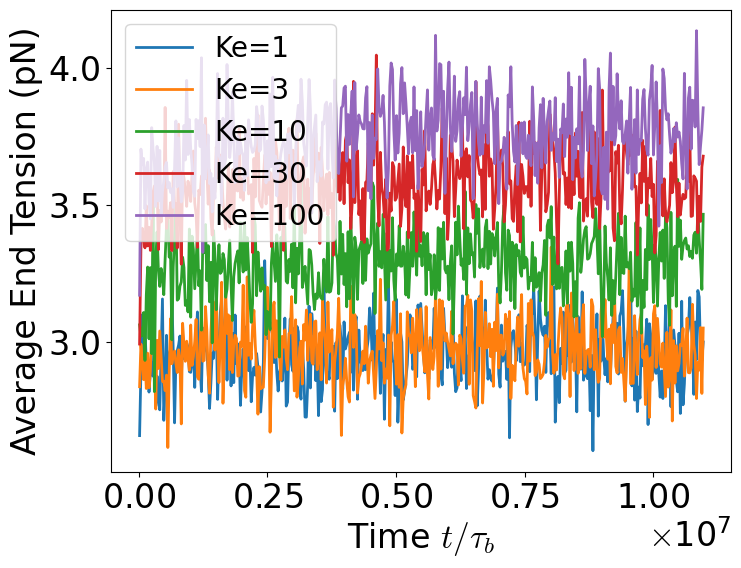

In [36]:
ell_val = 5
Ke_vals = [1, 3, 10, 30, 100]

fig, ax = plt.subplots(figsize=(8,6))
avg_tension_dict = {}
for Ke in Ke_vals:
    param_data_path = (ceph_path /f"DynCondPaper/24-03-08_aLc1_slice5.5.13_line1600_Pin3-11um_2xKe3-300_ks100/simulations/Ke{Ke}_Pin{ell_val}.0um")
    tension_arr_list = []
    for data_path in param_data_path.glob('s*/analysis'):
        with h5py.File(next(data_path.glob('raw_data.h5')), 'r+') as h5_data:
            time_arr = h5_data['time'][ss_ind:end_ind]/diff_time
            tension_arr = aa.get_link_tension(h5_data)[:,ss_ind:end_ind]
            end_tension_arr = (tension_arr[-1,:] + tension_arr[0,:]) * 0.5
            tension_arr_list.append(end_tension_arr)

    binned_time_avg, binned_tension_avg = bin_data(time_arr, np.mean(tension_arr_list, axis=0), bin_size=10.0/diff_time)
    avg_tension_dict[Ke] = binned_tension_avg

    _ = ax.xaxis.set_major_formatter(formatter)
    _ = ax.plot(binned_time_avg, binned_tension_avg, label=f"Ke={Ke}")
    _ = ax.set_xlabel("Time $t/\\tau_{b}$")
    _ = ax.set_ylabel("Average End Tension (pN)")
    _ = ax.legend()
avg_tension_data_dict[ell_val] = avg_tension_dict

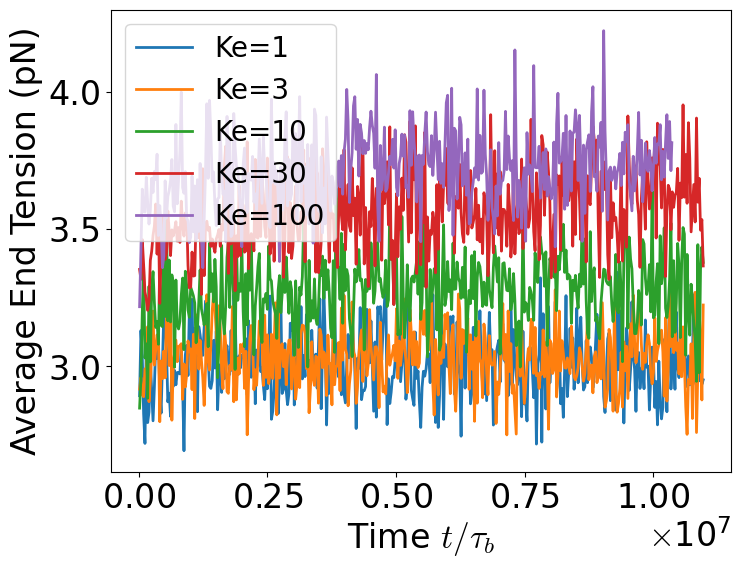

In [39]:
ell_val = 7
Ke_vals = [1, 3, 10, 30, 100]

fig, ax = plt.subplots(figsize=(8,6))
avg_tension_dict = {}
for Ke in Ke_vals:
    param_data_path = (ceph_path /f"DynCondPaper/24-03-08_aLc1_slice5.5.13_line1600_Pin3-11um_2xKe3-300_ks100/simulations/Ke{Ke}_Pin{ell_val}.0um")
    tension_arr_list = []
    for data_path in param_data_path.glob('s*/analysis'):
        with h5py.File(next(data_path.glob('raw_data.h5')), 'r+') as h5_data:
            time_arr = h5_data['time'][ss_ind:end_ind]/diff_time
            tension_arr = aa.get_link_tension(h5_data)[:,ss_ind:end_ind]
            end_tension_arr = (tension_arr[-1,:] + tension_arr[0,:]) * 0.5
            tension_arr_list.append(end_tension_arr)
    
    # Find minimum length and truncate all arrays
    min_length = min(len(arr) for arr in tension_arr_list)
    tension_arr_list = [arr[:min_length] for arr in tension_arr_list]
    time_arr = time_arr[:min_length]  # Also truncate time array

    binned_time_avg, binned_tension_avg = bin_data(time_arr, np.mean(tension_arr_list, axis=0), bin_size=10.0/diff_time)
    avg_tension_dict[Ke] = binned_tension_avg

    _ = ax.xaxis.set_major_formatter(formatter)
    _ = ax.plot(binned_time_avg, binned_tension_avg, label=f"Ke={Ke}")
    _ = ax.set_xlabel("Time $t/\\tau_{b}$")
    _ = ax.set_ylabel("Average End Tension (pN)")
    _ = ax.legend()
avg_tension_data_dict[ell_val] = avg_tension_dict

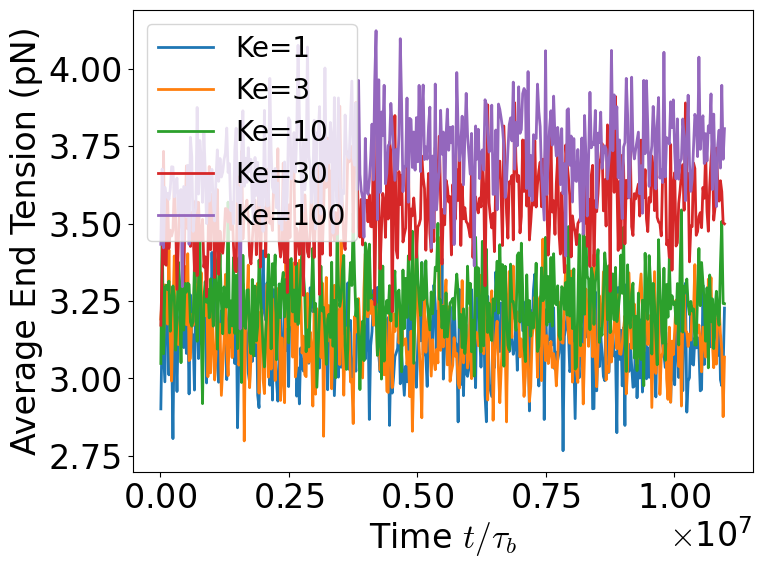

In [38]:
ell_val = 9
Ke_vals = [1, 3, 10, 30, 100]

fig, ax = plt.subplots(figsize=(8,6))
avg_tension_dict = {}
for Ke in Ke_vals:
    param_data_path = (ceph_path /f"DynCondPaper/24-03-08_aLc1_slice5.5.13_line1600_Pin3-11um_2xKe3-300_ks100/simulations/Ke{Ke}_Pin{ell_val}.0um")
    tension_arr_list = []
    for data_path in param_data_path.glob('s*/analysis'):
        with h5py.File(next(data_path.glob('raw_data.h5')), 'r+') as h5_data:
            time_arr = h5_data['time'][ss_ind:end_ind]/diff_time
            tension_arr = aa.get_link_tension(h5_data)[:,ss_ind:end_ind]
            end_tension_arr = (tension_arr[-1,:] + tension_arr[0,:]) * 0.5
            tension_arr_list.append(end_tension_arr)

    # Find minimum length and truncate all arrays
    min_length = min(len(arr) for arr in tension_arr_list)
    tension_arr_list = [arr[:min_length] for arr in tension_arr_list]
    time_arr = time_arr[:min_length]  # Also truncate time array

    binned_time_avg, binned_tension_avg = bin_data(time_arr, np.mean(tension_arr_list, axis=0), bin_size=10.0/diff_time)
    avg_tension_dict[Ke] = binned_tension_avg

    _ = ax.xaxis.set_major_formatter(formatter)
    _ = ax.plot(binned_time_avg, binned_tension_avg, label=f"Ke={Ke}")
    _ = ax.set_xlabel("Time $t/\\tau_{b}$")
    _ = ax.set_ylabel("Average End Tension (pN)")
    _ = ax.legend()
avg_tension_data_dict[ell_val] = avg_tension_dict

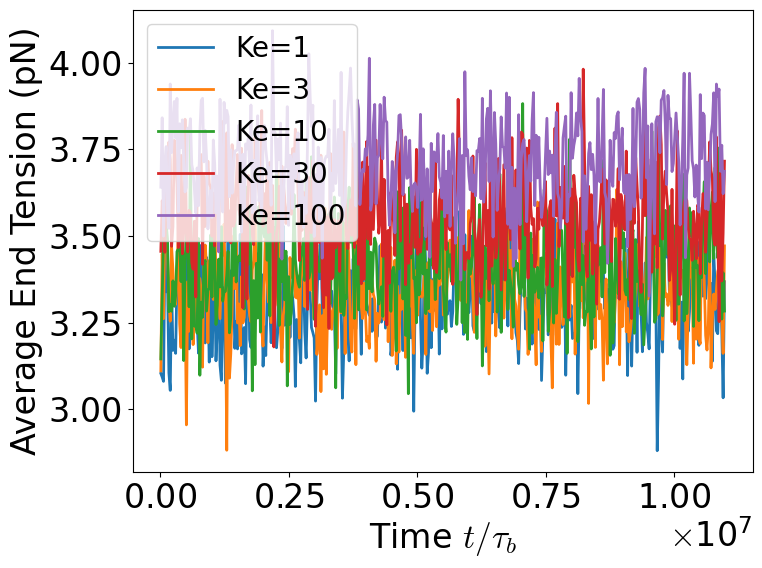

In [40]:
ell_val = 11
Ke_vals = [1, 3, 10, 30, 100]

fig, ax = plt.subplots(figsize=(8,6))
avg_tension_dict = {}
for Ke in Ke_vals:
    param_data_path = (ceph_path /f"DynCondPaper/24-03-08_aLc1_slice5.5.13_line1600_Pin3-11um_2xKe3-300_ks100/simulations/Ke{Ke}_Pin{ell_val}.0um")
    tension_arr_list = []
    for data_path in param_data_path.glob('s*/analysis'):
        with h5py.File(next(data_path.glob('raw_data.h5')), 'r+') as h5_data:
            time_arr = h5_data['time'][ss_ind:end_ind]/diff_time
            tension_arr = aa.get_link_tension(h5_data)[:,ss_ind:end_ind]
            end_tension_arr = (tension_arr[-1,:] + tension_arr[0,:]) * 0.5
            tension_arr_list.append(end_tension_arr)

    binned_time_avg, binned_tension_avg = bin_data(time_arr, np.mean(tension_arr_list, axis=0), bin_size=10.0/diff_time)
    avg_tension_dict[Ke] = binned_tension_avg

    _ = ax.xaxis.set_major_formatter(formatter)
    _ = ax.plot(binned_time_avg, binned_tension_avg, label=f"Ke={Ke}")
    _ = ax.set_xlabel("Time $t/\\tau_{b}$")
    _ = ax.set_ylabel("Average End Tension (pN)")
    _ = ax.legend()
avg_tension_data_dict[ell_val] = avg_tension_dict

In [41]:
# Save data
with h5py.File("avg_tension_data.h5", 'w') as h5_file:
    for ell, tension_dict in avg_tension_data_dict.items():
        ell_group = h5_file.create_group(f"ell_{ell}")
        for Ke, tension_data in tension_dict.items():
            ell_group.create_dataset(f"Ke_{Ke}", data=tension_data)
    time_dset = h5_file.create_dataset("time", data=binned_time_avg)

# Play

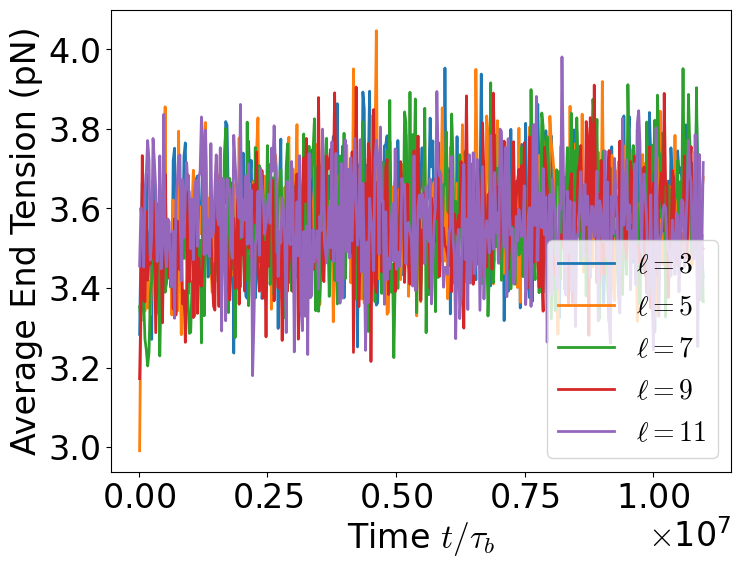

In [ ]:
l_vals = [3, 5, 7, 9, 11]

fig, ax = plt.subplots(figsize=(8,6))
l_avg_tension_dict = {}
for l in l_vals:
    param_data_path = (ceph_path /f"DynCondPaper/24-03-08_aLc1_slice5.5.13_line1600_Pin3-11um_2xKe3-300_ks100/simulations/Ke30_Pin{l}.0um")
    tension_arr_list = []
    for data_path in param_data_path.glob('s*/analysis'):
        with h5py.File(next(data_path.glob('raw_data.h5')), 'r+') as h5_data:
            time_arr = h5_data['time'][ss_ind:end_ind]/diff_time
            tension_arr = aa.get_link_tension(h5_data)[:,ss_ind:end_ind]
            end_tension_arr = (tension_arr[-1,:] + tension_arr[0,:]) * 0.5
            tension_arr_list.append(end_tension_arr)

    binned_time_avg, binned_tension_avg = bin_data(time_arr, np.mean(tension_arr_list, axis=0), bin_size=10.0/diff_time)
    l_avg_tension_dict[l] = binned_tension_avg

    _ = ax.xaxis.set_major_formatter(formatter)
    _ = ax.plot(binned_time_avg, binned_tension_avg, label=f"$\ell={l}$")
    _ = ax.set_xlabel("Time $t/\\tau_{b}$")
    _ = ax.set_ylabel("Average End Tension (pN)")
    _ = ax.legend()